In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

In [3]:

true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05


In [5]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

In [6]:
def l2_penalty(w):
    return torch.sum(w.pow(2))/2

In [7]:
def train(lambd):
    w,b=init_params()
    net,loss=lambda X:d2l.linreg(X,w,b),d2l.squared_loss
    num_epochs,lr = 100,0.03
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X,y in train_iter:
            l=loss(net(X),y)+lambd*l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w,b],lr,batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                    d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())


w的L2范数是： 14.7779541015625


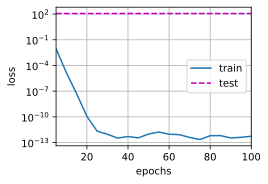

In [8]:
train(lambd=0)

w的L2范数是： 0.04120173677802086


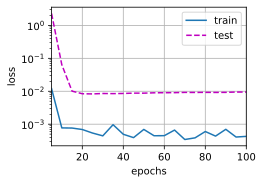

In [9]:
train(lambd=3)


w的L2范数是： 0.040132805705070496


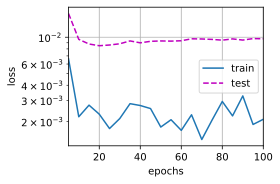

In [10]:
train(lambd=8)

In [39]:
def train_concise(wd):
    net=nn.Sequential(nn.Linear(num_inputs,1)) #表示只有一层，相当于线性计算 ，输入与输出维度
    for param in net.parameters():
        param.data.normal_()
    loss =nn.MSELoss(reduction='none') #reduction 控制损失函数的输出格式，none向量。mean标量
    num_epochs,lr = 1000,0.001
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd}, # 故 net【0】就是原始的w,b
        {"params":net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X,y in train_iter:
           # trainer.zero_grad()
            l=loss(net(X),y)
            l.mean().backward() #先对loss返回的向量，求平均-》标量，在反向传播
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                    (d2l.evaluate_loss(net, train_iter, loss),
                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())


w的L2范数： 0.04824690893292427


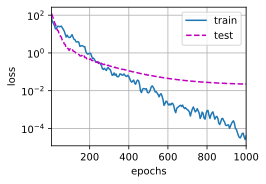

In [40]:
train_concise(9)